# GLOBAL E-COMMERCE RETURN & REFUND INTELLIGENCE
### A Multi-Market Analysis | UK · Brazil · Global Logistics

### SETUPS AND IMPORTS

In [1]:
%pip install pandas numpy matplotlib seaborn openpyxl -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
import sqlite3
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D',
          '#44BBA4', '#3B1F2B', '#E94F37', '#393E41']
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize'   : (14, 6),
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("  GLOBAL E-COMMERCE RETURN & REFUND INTELLIGENCE")
print("       Multi-Market: UK · Brazil · Global Logistics")
print("\n Libraries loaded. Ready to analyse!\n")

  GLOBAL E-COMMERCE RETURN & REFUND INTELLIGENCE
       Multi-Market: UK · Brazil · Global Logistics

 Libraries loaded. Ready to analyse!



### DATA LOADING

In [4]:
# Dataset 1: Online Retail II — UK Market 
print("Loading UK Market (Online Retail II)...")
df_uk_raw = pd.read_csv('online_retail_II.csv', encoding='unicode_escape')
print(f"   {df_uk_raw.shape[0]:,} rows | {df_uk_raw.shape[1]} columns")
print(f"   Columns: {list(df_uk_raw.columns)}\n")

Loading UK Market (Online Retail II)...
   1,067,371 rows | 8 columns
   Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']



In [5]:
# Dataset 2: Olist — Brazil Market
print("Loading Brazil Market (Olist — 8 tables)...")
df_orders    = pd.read_csv('olist_orders_dataset.csv')
df_items     = pd.read_csv('olist_order_items_dataset.csv')
df_products  = pd.read_csv('olist_products_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_sellers   = pd.read_csv('olist_sellers_dataset.csv')
df_reviews   = pd.read_csv('olist_order_reviews_dataset.csv')
df_payments  = pd.read_csv('olist_order_payments_dataset.csv')
df_category  = pd.read_csv('product_category_name_translation.csv')
print(f"   Orders: {len(df_orders):,} | Items: {len(df_items):,} | Reviews: {len(df_reviews):,}\n")

Loading Brazil Market (Olist — 8 tables)...
   Orders: 99,441 | Items: 112,650 | Reviews: 99,224



In [6]:
# Dataset 3: E-Commerce Shipping — Logistics
print("Loading Logistics Dataset (E-Commerce Shipping)...")
df_ship = pd.read_csv('Train.csv')
print(f"   {df_ship.shape[0]:,} rows | {df_ship.shape[1]} columns")
print(f"   Columns: {list(df_ship.columns)}")

Loading Logistics Dataset (E-Commerce Shipping)...
   10,999 rows | 12 columns
   Columns: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


### UK MARKET — DATA CLEANING & RETURN IDENTIFICATION

In [8]:
df_uk = pd.read_csv('online_retail_II.csv', encoding='unicode_escape')

# Basic Exploration 
print("Shape:", df_uk.shape)
print("\n Data Types:\n", df_uk.dtypes)
print("\n Missing Values:\n", df_uk.isnull().sum())
display(df_uk.head())
display(df_uk.describe())

# Cleaning 
df_uk.columns = df_uk.columns.str.strip()

before = len(df_uk)
df_uk = df_uk.dropna(subset=['Customer ID'])
print(f" Removed {before - len(df_uk):,} rows — missing Customer ID")

before = len(df_uk)
df_uk = df_uk.drop_duplicates()
print(f" Removed {before - len(df_uk):,} rows — duplicates")

before = len(df_uk)
df_uk = df_uk[df_uk['Price'] > 0]
print(f" Removed {before - len(df_uk):,} rows — zero/negative price")

# Feature Engineering
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'])
df_uk['Customer ID'] = df_uk['Customer ID'].astype(int).astype(str)
df_uk['Year']        = df_uk['InvoiceDate'].dt.year
df_uk['Month']       = df_uk['InvoiceDate'].dt.month
df_uk['YearMonth']   = df_uk['InvoiceDate'].dt.to_period('M').astype(str)
df_uk['DayOfWeek']   = df_uk['InvoiceDate'].dt.day_name()
df_uk['Hour']        = df_uk['InvoiceDate'].dt.hour
df_uk['TotalValue']  = df_uk['Quantity'] * df_uk['Price']

# Identify Returns
# Invoice starting with 'C' OR Quantity < 0 = Return
df_uk['IsReturn']     = df_uk['Invoice'].astype(str).str.startswith('C') | (df_uk['Quantity'] < 0)
df_uk_returns         = df_uk[df_uk['IsReturn'] == True].copy()
df_uk_sales           = df_uk[df_uk['IsReturn'] == False].copy()
df_uk_returns['RefundAmount'] = df_uk_returns['TotalValue'].abs()

# Summary 
print(f"\n  Total Transactions : {len(df_uk):,}")
print(f"  Normal Sales       : {len(df_uk_sales):,}")
print(f"  Returns            : {len(df_uk_returns):,}")
print(f"  Return Rate        : {len(df_uk_returns)/len(df_uk)*100:.2f}%")
print(f"  Total Refund Value : £{df_uk_returns['RefundAmount'].sum():,.2f}")
print(f"  Unique Customers   : {df_uk['Customer ID'].nunique():,}")
print(f"  Unique Products    : {df_uk['StockCode'].nunique():,}")
print(f"  Countries          : {df_uk['Country'].nunique()}")
print(f"  Date Range         : {df_uk['InvoiceDate'].min().date()} → {df_uk['InvoiceDate'].max().date()}")

Shape: (1067371, 8)

 Data Types:
 Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

 Missing Values:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


,Quantity,Price,Customer ID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00


 Removed 243,007 rows — missing Customer ID
 Removed 26,479 rows — duplicates
 Removed 70 rows — zero/negative price

  Total Transactions : 797,815
  Normal Sales       : 779,425
  Returns            : 18,390
  Return Rate        : 2.31%
  Total Refund Value : £1,084,812.98
  Unique Customers   : 5,939
  Unique Products    : 4,646
  Countries          : 41
  Date Range         : 2009-12-01 → 2011-12-09


### UK MARKET — EDA VISUALIZATIONS

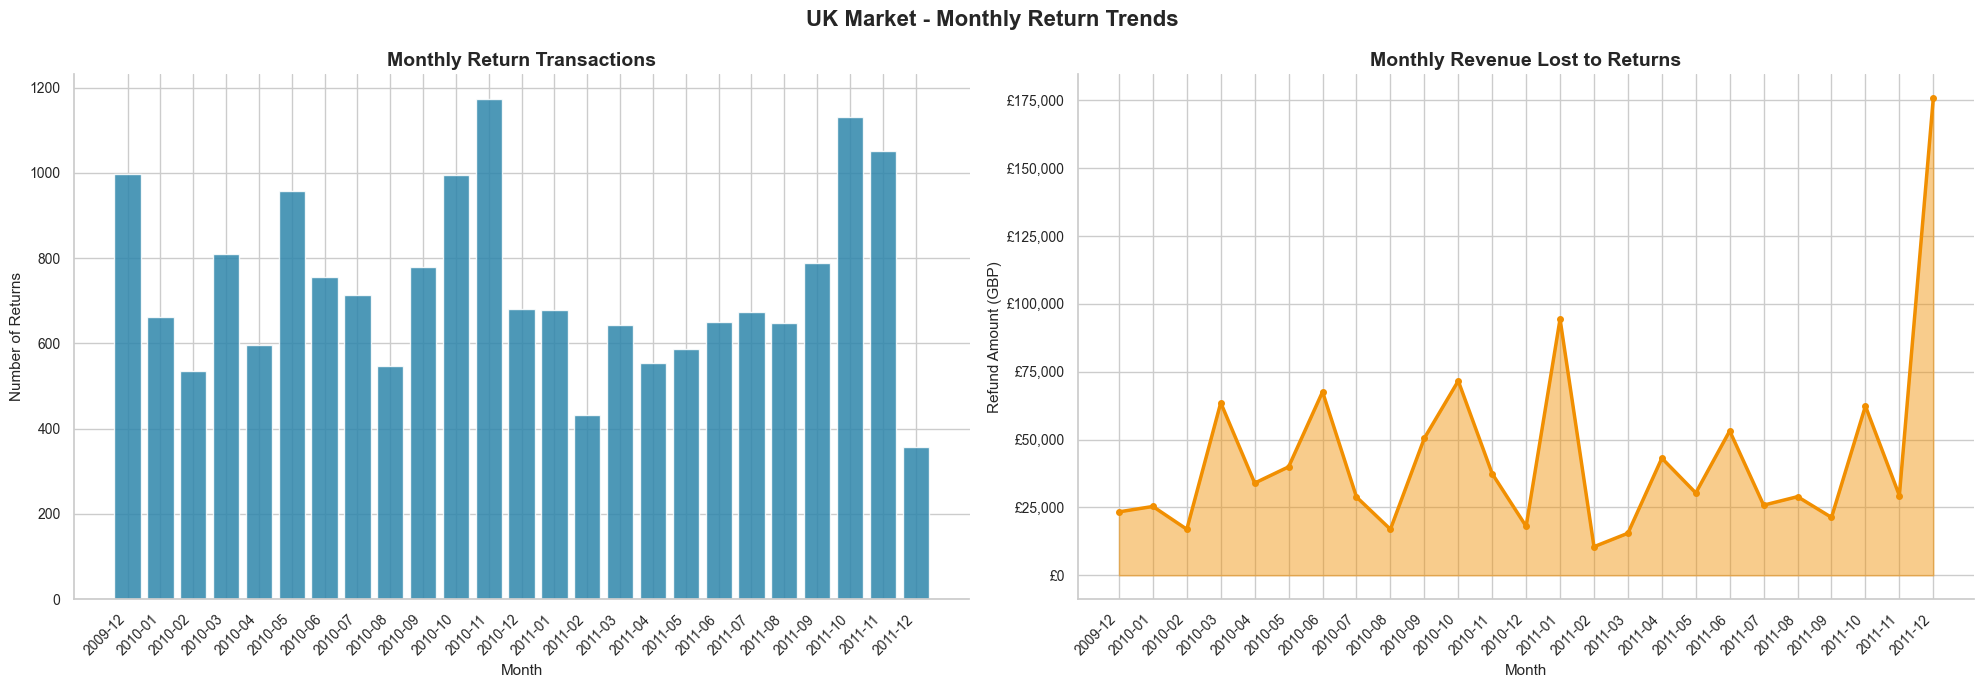

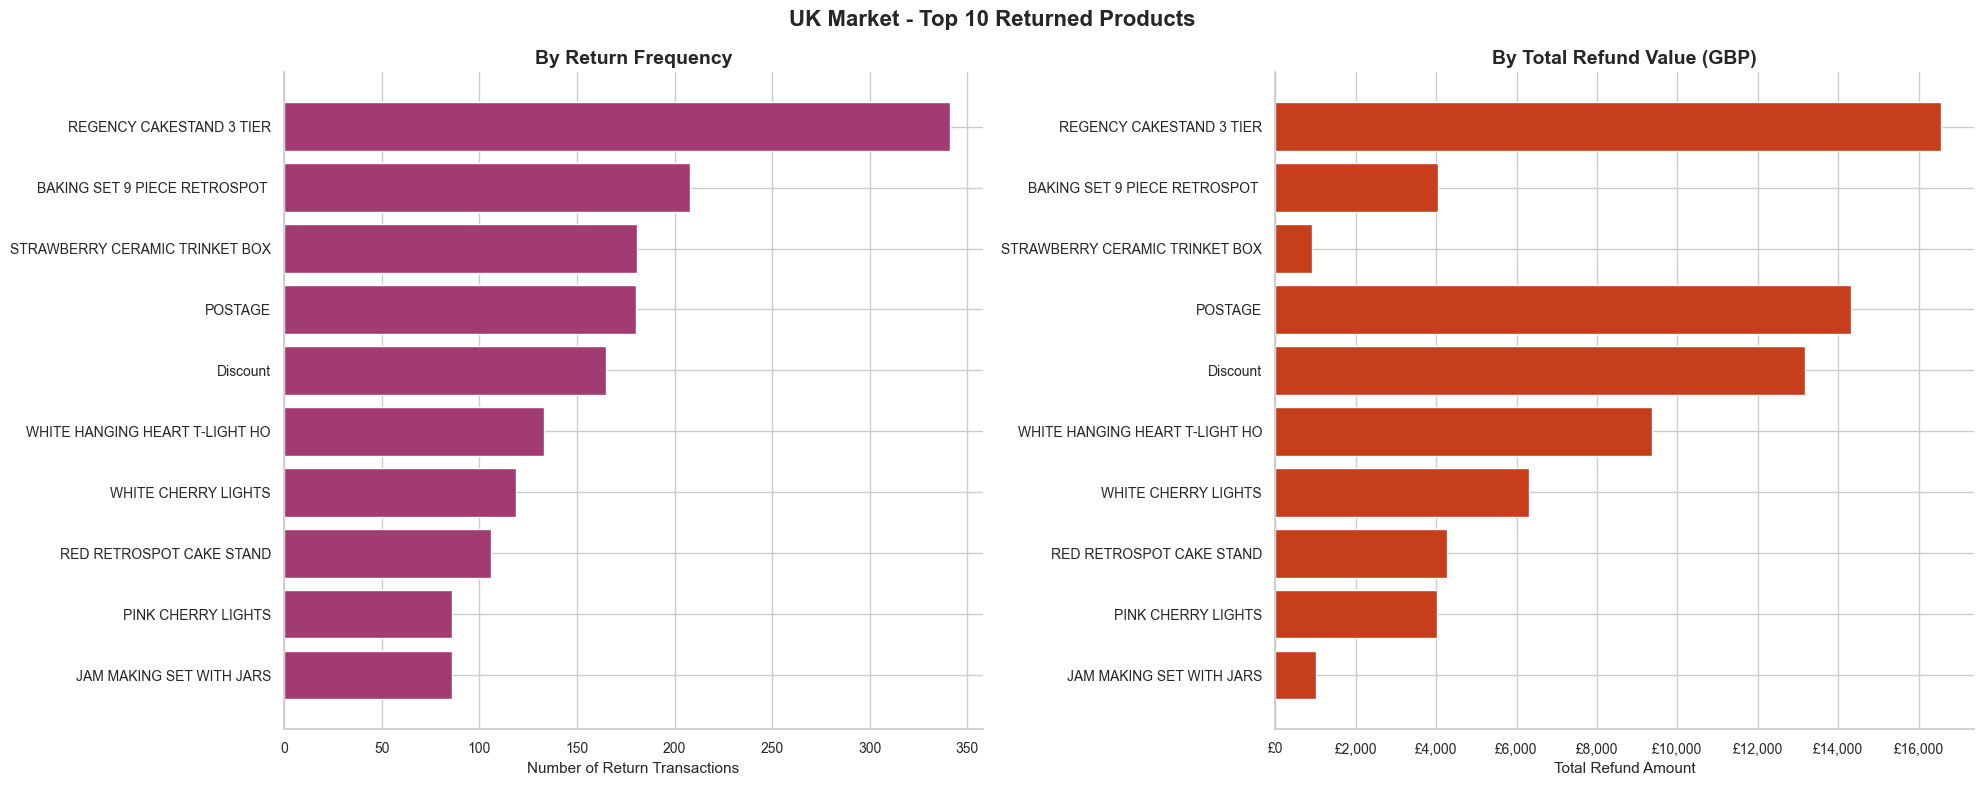

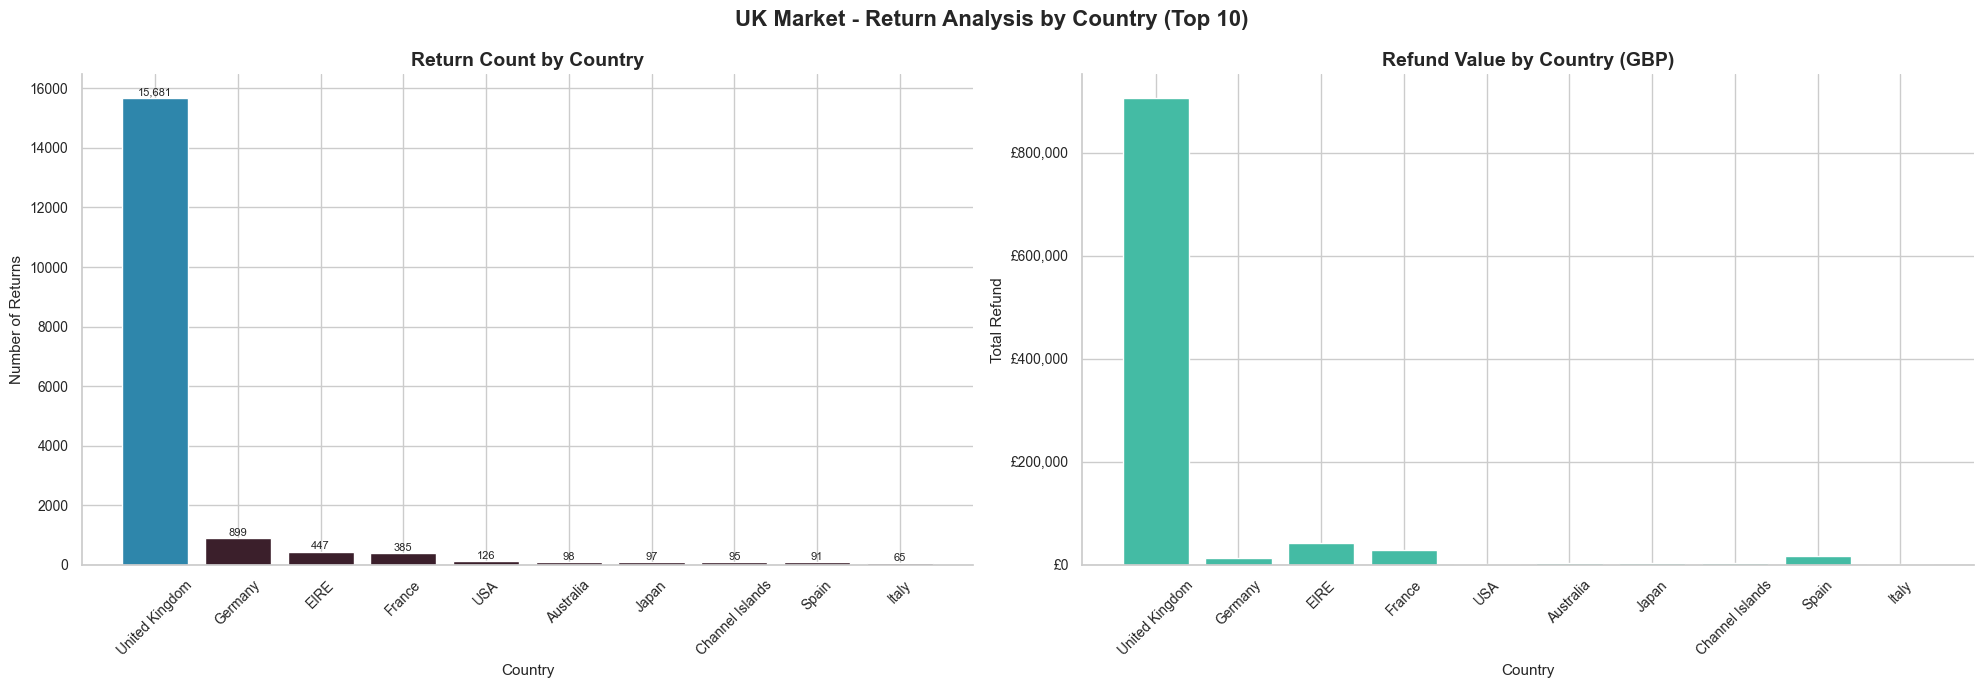

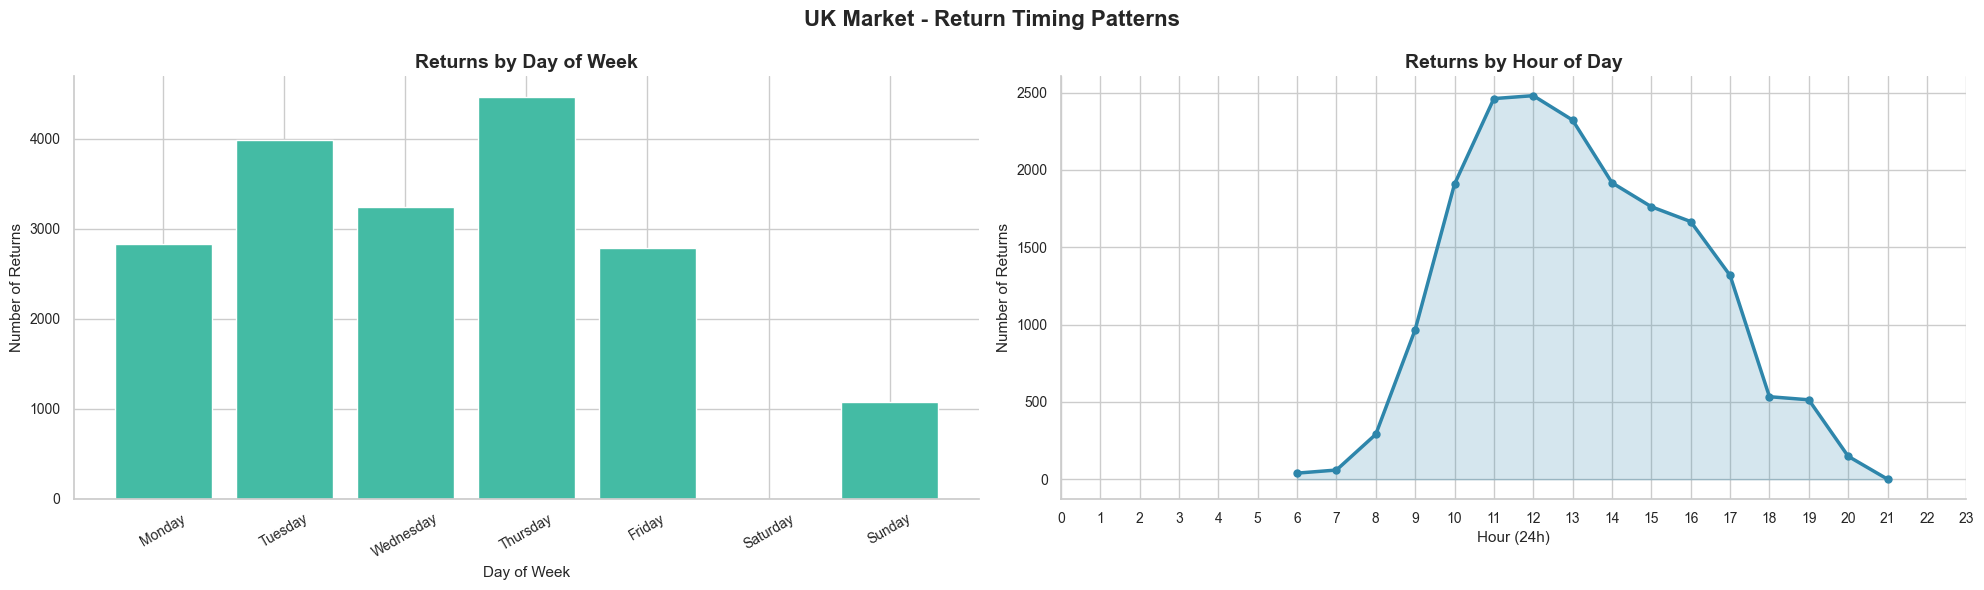

UK Market - Key Findings
Return Rate          : 2.31%
Revenue Lost         : £1,084,812.98
Top Returned Product : REGENCY CAKESTAND 3 TIER
Top Return Country   : United Kingdom
Peak Return Day      : Thursday


In [9]:
# 4.1 Monthly Return Trend
monthly_ret = df_uk_returns.groupby('YearMonth').agg(
    Return_Count=('Invoice', 'count'),
    Total_Refund=('RefundAmount', 'sum')
).reset_index().sort_values('YearMonth')

monthly_sal = df_uk_sales.groupby('YearMonth').agg(
    Sales_Count=('Invoice', 'count')
).reset_index()

monthly = monthly_ret.merge(monthly_sal, on='YearMonth', how='outer').fillna(0)
monthly['Return_Rate_%'] = (monthly['Return_Count'] / (monthly['Return_Count'] + monthly['Sales_Count']) * 100).round(2)

x = range(len(monthly))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('UK Market - Monthly Return Trends', fontsize=16, fontweight='bold')

axes[0].bar(x, monthly['Return_Count'], color=COLORS[0], alpha=0.85, edgecolor='white')
axes[0].set_title('Monthly Return Transactions')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Returns')
axes[0].set_xticks(x)
axes[0].set_xticklabels(monthly['YearMonth'], rotation=45, ha='right')

axes[1].fill_between(x, monthly['Total_Refund'], color=COLORS[2], alpha=0.45)
axes[1].plot(x, monthly['Total_Refund'], color=COLORS[2], linewidth=2.5, marker='o', markersize=4)
axes[1].set_title('Monthly Revenue Lost to Returns')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Refund Amount (GBP)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(monthly['YearMonth'], rotation=45, ha='right')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'£{v:,.0f}'))

plt.tight_layout()
plt.savefig('uk_monthly_returns.png', dpi=150, bbox_inches='tight')
plt.show()


# 4.2 Top 10 Returned Products
top_returned = (
    df_uk_returns.groupby('Description')
    .agg(Return_Count=('Quantity', 'count'), Total_Refund=('RefundAmount', 'sum'))
    .reset_index()
    .query("Description.notna() and Description != 'Manual'", engine='python')
    .sort_values('Return_Count', ascending=False)
    .head(10)
)
top_returned['Short_Name'] = top_returned['Description'].str[:30]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('UK Market - Top 10 Returned Products', fontsize=16, fontweight='bold')

axes[0].barh(top_returned['Short_Name'], top_returned['Return_Count'], color=COLORS[1], edgecolor='white')
axes[0].set_title('By Return Frequency')
axes[0].set_xlabel('Number of Return Transactions')
axes[0].invert_yaxis()

axes[1].barh(top_returned['Short_Name'], top_returned['Total_Refund'], color=COLORS[3], edgecolor='white')
axes[1].set_title('By Total Refund Value (GBP)')
axes[1].set_xlabel('Total Refund Amount')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('uk_top_returned_products.png', dpi=150, bbox_inches='tight')
plt.show()


# 4.3 Country-wise Return Analysis
country_ret = (
    df_uk_returns.groupby('Country')
    .agg(Return_Count=('Invoice', 'count'), Refund_Value=('RefundAmount', 'sum'))
    .reset_index()
    .sort_values('Return_Count', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('UK Market - Return Analysis by Country (Top 10)', fontsize=16, fontweight='bold')

colors_country = [COLORS[0] if i == 0 else COLORS[5] for i in range(len(country_ret))]
bars = axes[0].bar(country_ret['Country'], country_ret['Return_Count'], color=colors_country, edgecolor='white')
axes[0].set_title('Return Count by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Returns')
axes[0].tick_params(axis='x', rotation=45)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

axes[1].bar(country_ret['Country'], country_ret['Refund_Value'], color=COLORS[4], edgecolor='white')
axes[1].set_title('Refund Value by Country (GBP)')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Total Refund')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'£{v:,.0f}'))

plt.tight_layout()
plt.savefig('uk_country_returns.png', dpi=150, bbox_inches='tight')
plt.show()


# 4.4 Day of Week and Hour Pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_ret = df_uk_returns.groupby('DayOfWeek').size().reindex(day_order).reset_index(name='Returns')
hour_ret = df_uk_returns.groupby('Hour').size().reset_index(name='Returns')

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('UK Market - Return Timing Patterns', fontsize=16, fontweight='bold')

axes[0].bar(day_ret['DayOfWeek'], day_ret['Returns'], color=COLORS[4], edgecolor='white')
axes[0].set_title('Returns by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Returns')
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(hour_ret['Hour'], hour_ret['Returns'], color=COLORS[0], linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(hour_ret['Hour'], hour_ret['Returns'], color=COLORS[0], alpha=0.2)
axes[1].set_title('Returns by Hour of Day')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Number of Returns')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('uk_timing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


# Key Findings
print("UK Market - Key Findings")
print(f"Return Rate          : {len(df_uk_returns)/len(df_uk)*100:.2f}%")
print(f"Revenue Lost         : £{df_uk_returns['RefundAmount'].sum():,.2f}")
print(f"Top Returned Product : {top_returned.iloc[0]['Description']}")
print(f"Top Return Country   : {country_ret.iloc[0]['Country']}")
print(f"Peak Return Day      : {day_ret.sort_values('Returns', ascending=False).iloc[0]['DayOfWeek']}")

### BRAZIL MARKET — DATA PREPARATION (OLIST)

In [13]:
import pandas as pd

# Helper function to safely extract mode values
def safe_mode(series, default='Unknown'):
    """
    Returns the first mode of a pandas Series if available,
    otherwise returns a default value.
    """
    m = series.mode()
    return m.iloc[0] if len(m) > 0 else default

# Translate product categories to English
df_products_en = df_products.merge(df_category, on='product_category_name', how='left')
df_products_en['category_en'] = (
    df_products_en['product_category_name_english']
    .fillna(df_products_en['product_category_name'])
    .str.replace('_', ' ')
    .str.title()
)

# Merge items with product categories
items_with_cat = df_items.merge(
    df_products_en[['product_id', 'category_en']], on='product_id', how='left'
)

# Aggregate to order level
order_agg = items_with_cat.groupby('order_id').agg(
    total_value      = ('price', 'sum'),                       # total price per order
    freight_value    = ('freight_value', 'sum'),               # total freight per order
    item_count       = ('order_item_id', 'count'),             # number of items per order
    product_category = ('category_en', lambda x: safe_mode(x)) # most common category
).reset_index()

# Worst review per order (minimum score)
review_agg = df_reviews.groupby('order_id').agg(
    review_score=('review_score', 'min')
).reset_index()

# Payment aggregation
payment_agg = df_payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),                    # total payment per order
    payment_type =('payment_type', lambda x: safe_mode(x))     # most common payment type
).reset_index()

# Build master dataframe with customers, orders, items, reviews, payments
df_brazil = df_orders.merge(
    df_customers[['customer_id', 'customer_state', 'customer_city']], 
    on='customer_id', how='left'
)
df_brazil = df_brazil.merge(order_agg,   on='order_id', how='left')
df_brazil = df_brazil.merge(review_agg,  on='order_id', how='left')
df_brazil = df_brazil.merge(payment_agg, on='order_id', how='left')

# Fix date columns
date_cols = [
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'order_approved_at'
]
for col in date_cols:
    df_brazil[col] = pd.to_datetime(df_brazil[col])

# Feature engineering
df_brazil['delivery_delay_days'] = (
    df_brazil['order_delivered_customer_date'] -
    df_brazil['order_estimated_delivery_date']
).dt.days

df_brazil['approval_hours'] = (
    df_brazil['order_approved_at'] -
    df_brazil['order_purchase_timestamp']
).dt.total_seconds() / 3600

df_brazil['is_late']      = df_brazil['delivery_delay_days'] > 0
df_brazil['is_cancelled'] = df_brazil['order_status'] == 'canceled'
df_brazil['YearMonth']    = df_brazil['order_purchase_timestamp'].dt.to_period('M').astype(str)
df_brazil['Year']         = df_brazil['order_purchase_timestamp'].dt.year

# Subset delivered orders
delivered = df_brazil[df_brazil['order_status'] == 'delivered'].copy()

# Summary statistics
print(f"Master Brazil DataFrame: {df_brazil.shape[0]:,} rows x {df_brazil.shape[1]} columns")
print(f"\nOrder Status Breakdown:")
print(df_brazil['order_status'].value_counts())
print(f"\nBrazil Market Summary")
print(f"Total Orders      : {len(df_brazil):,}")
print(f"Cancellation Rate : {df_brazil['is_cancelled'].mean()*100:.2f}%")
print(f"Delivered Orders  : {(df_brazil['order_status']=='delivered').sum():,}")
print(f"Late Deliveries   : {delivered['is_late'].sum():,} ({delivered['is_late'].mean()*100:.2f}% of delivered)")
print(f"Avg Review Score  : {df_brazil['review_score'].mean():.2f} / 5")
print(f"Date Range        : {df_brazil['order_purchase_timestamp'].min().date()} to {df_brazil['order_purchase_timestamp'].max().date()}")

Master Brazil DataFrame: 99,441 rows x 23 columns

Order Status Breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Brazil Market Summary
Total Orders      : 99,441
Cancellation Rate : 0.63%
Delivered Orders  : 96,478
Late Deliveries   : 6,534 (6.77% of delivered)
Avg Review Score  : 4.08 / 5
Date Range        : 2016-09-04 to 2018-10-17


### BRAZIL MARKET — EDA VISUALIZATIONS

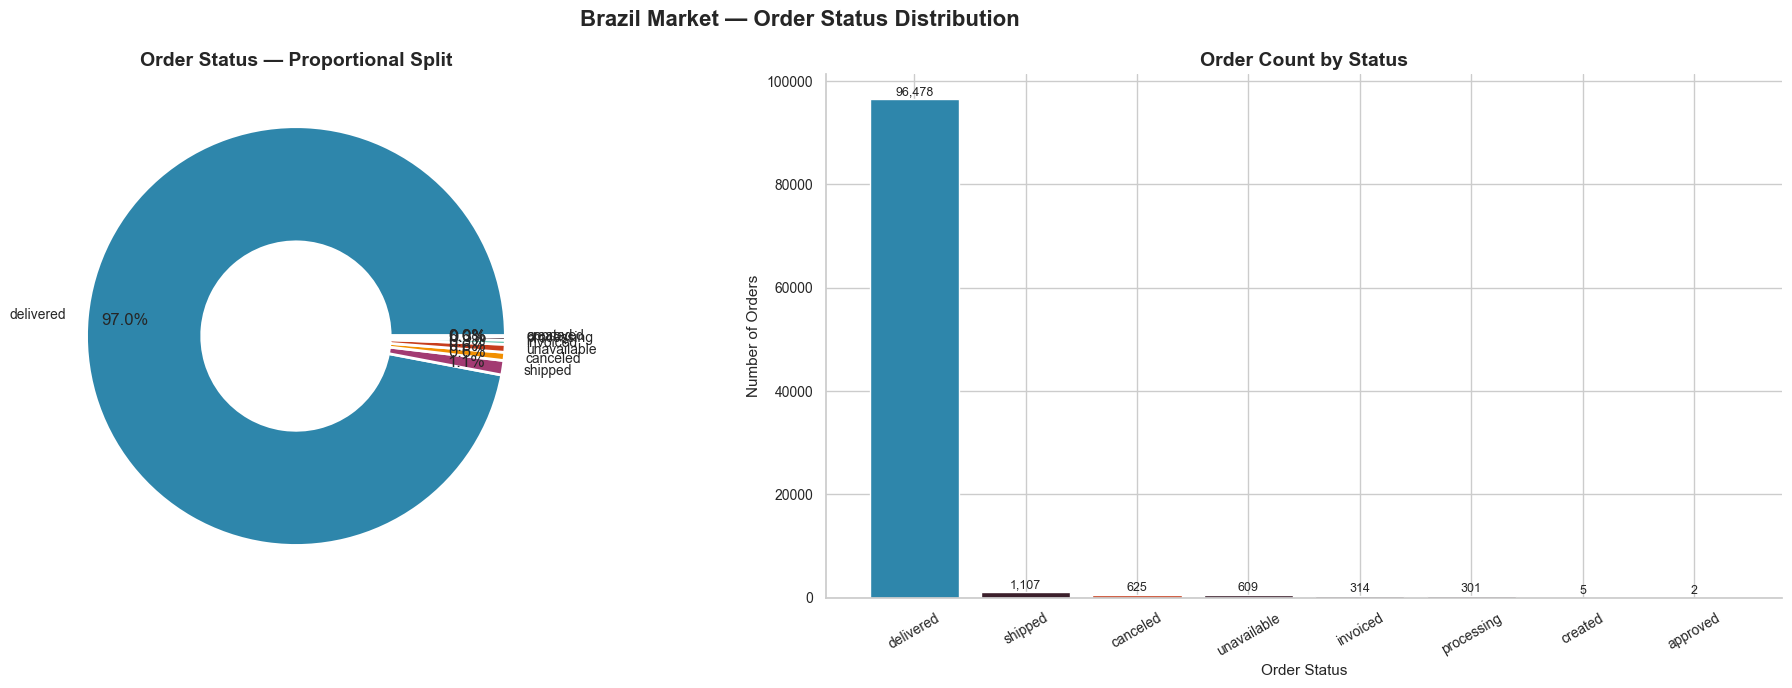

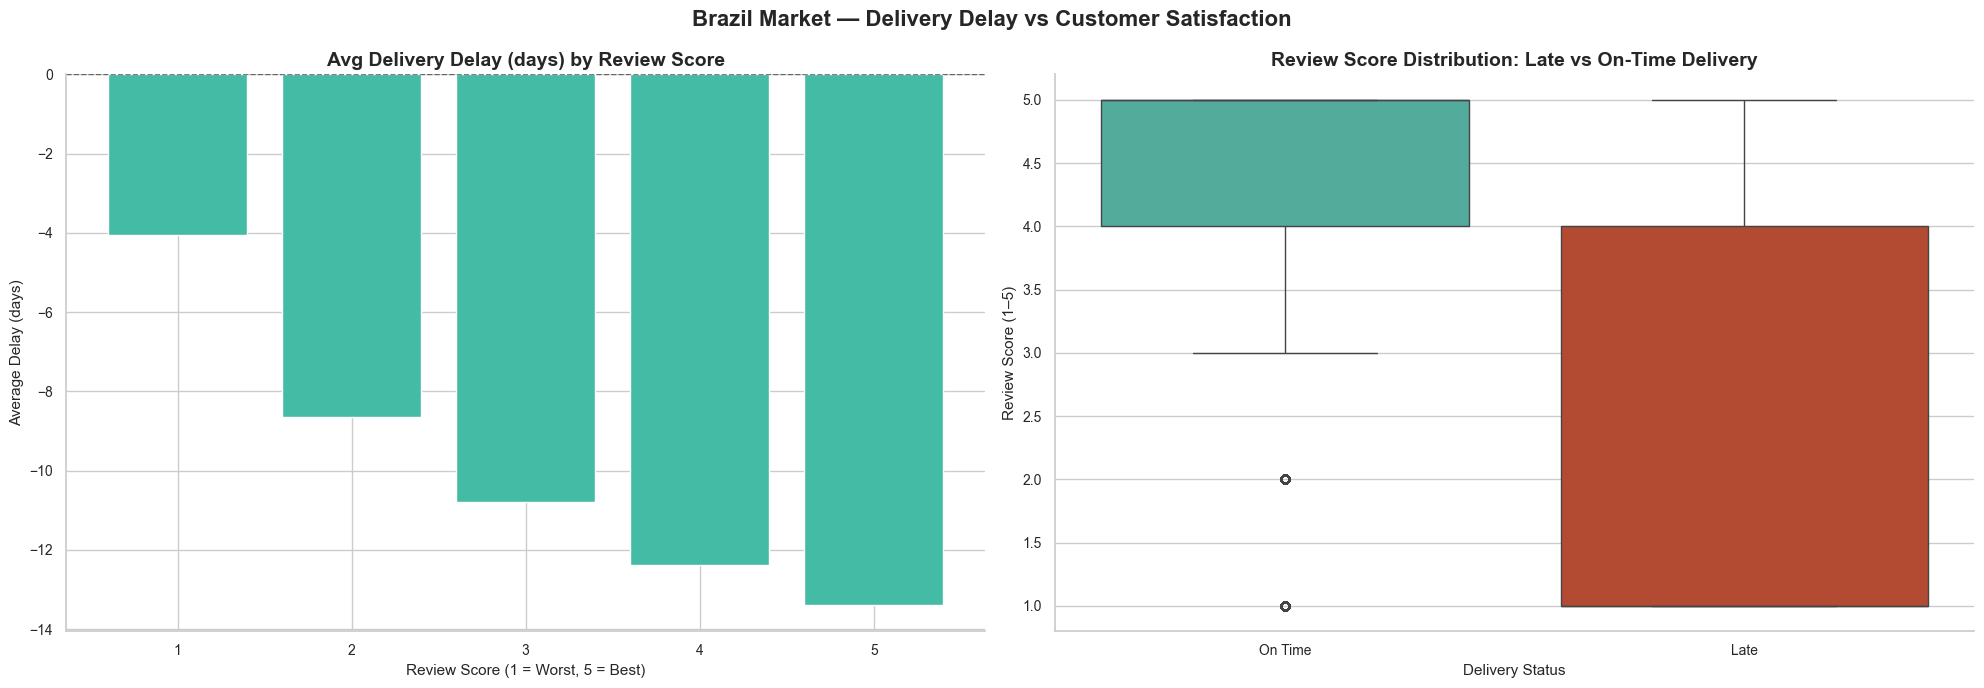

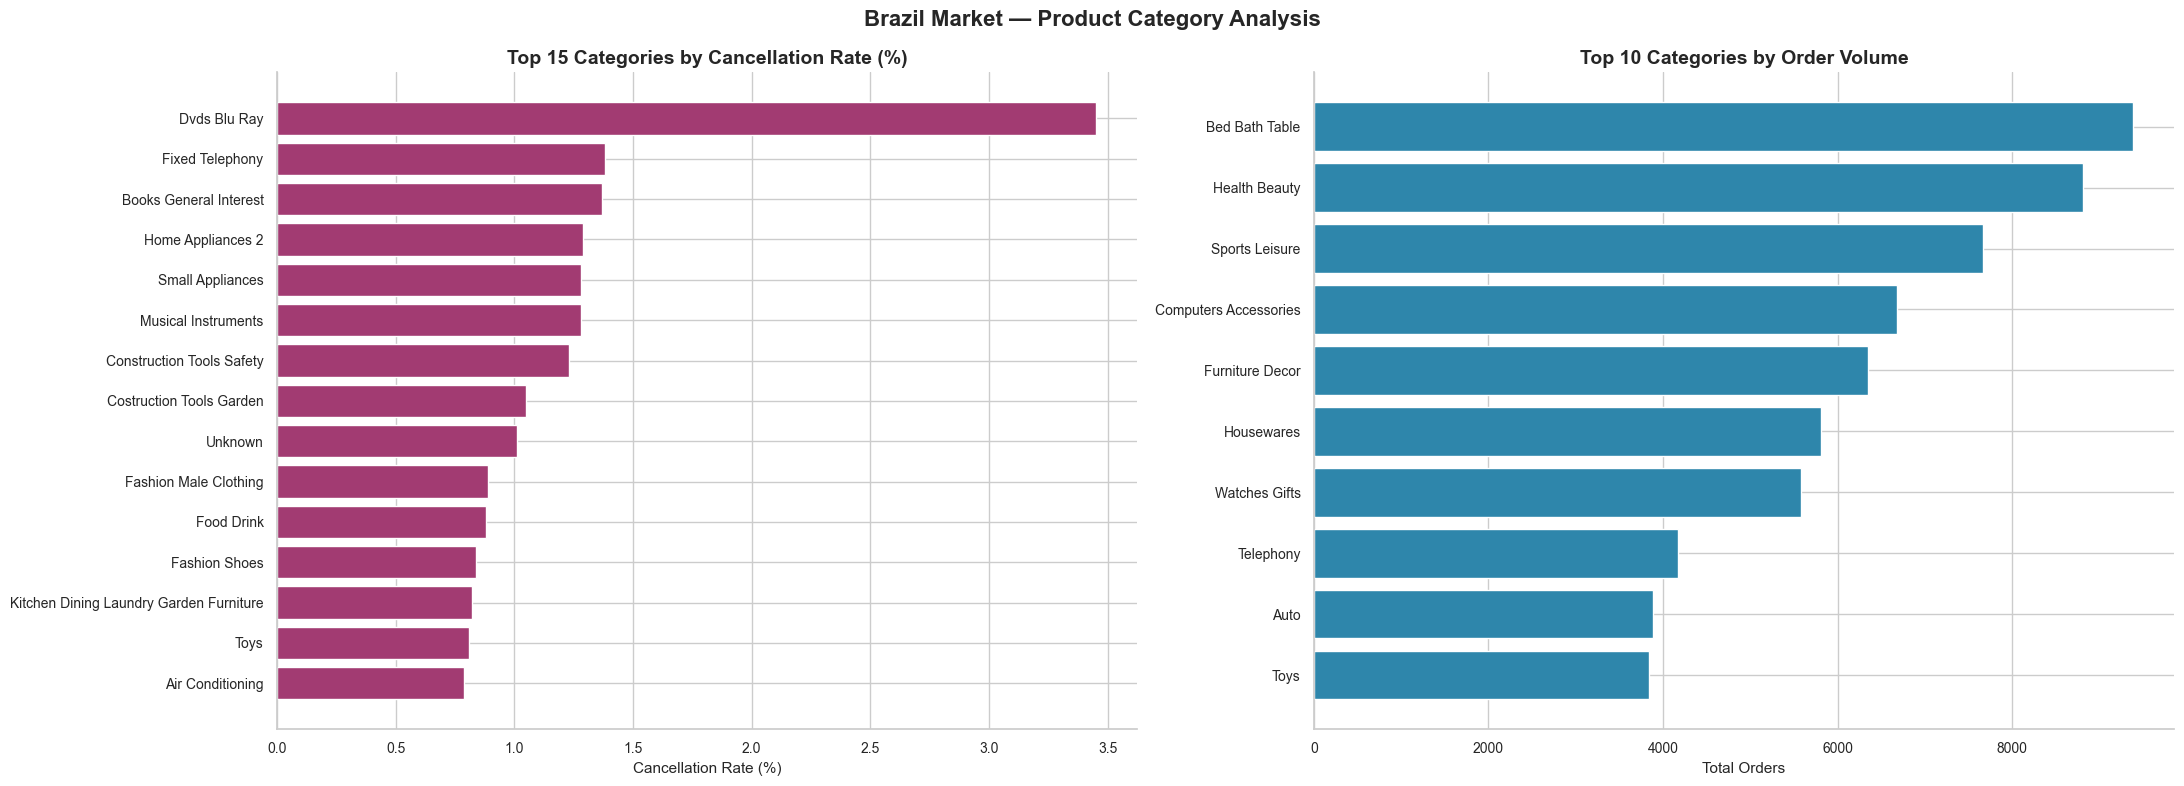

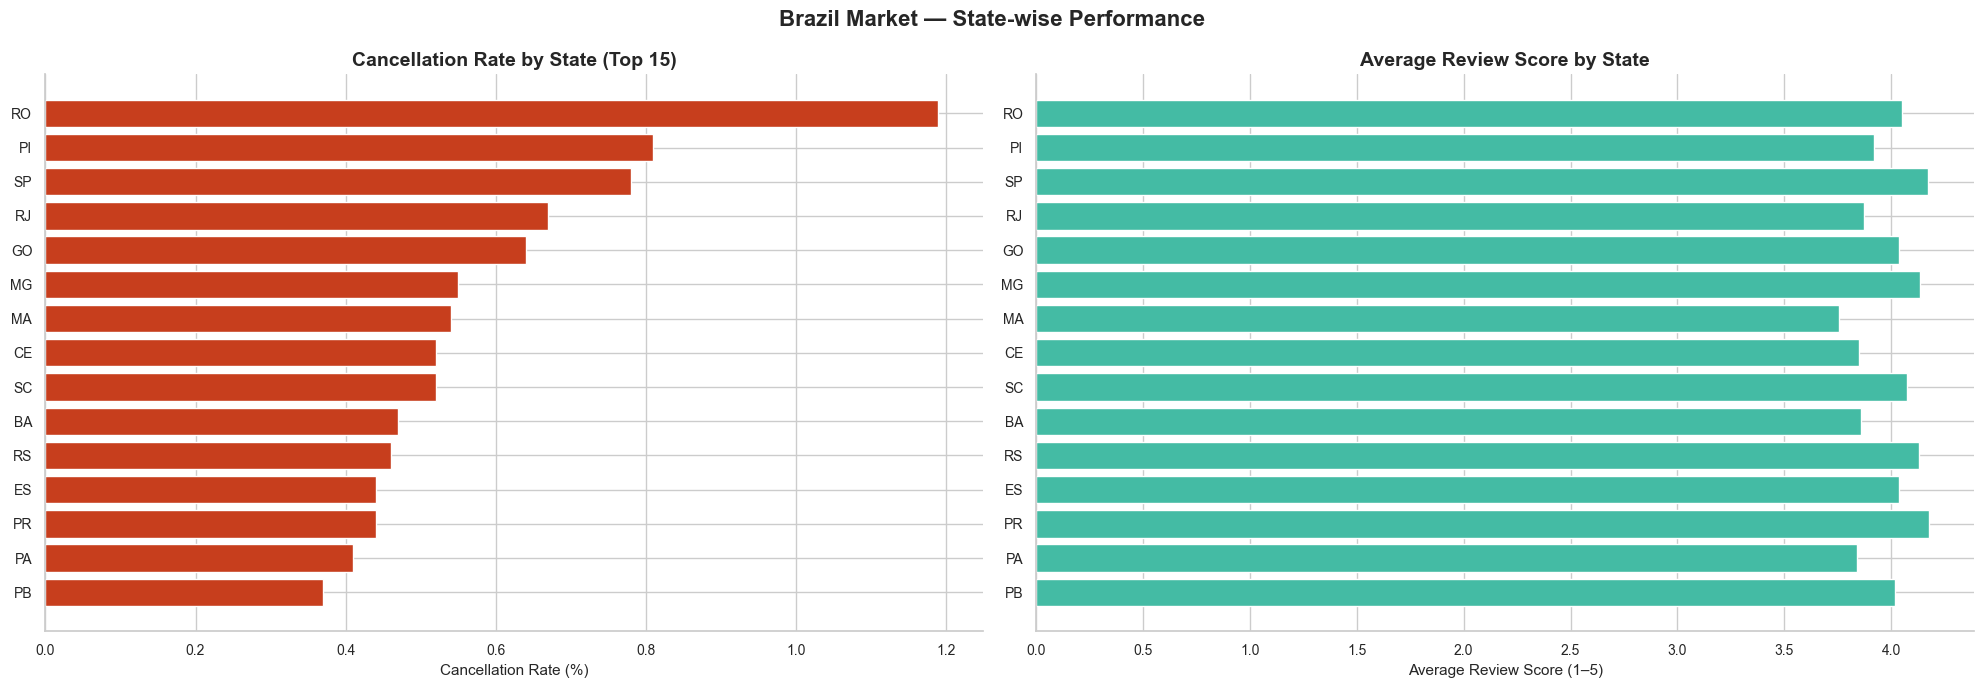

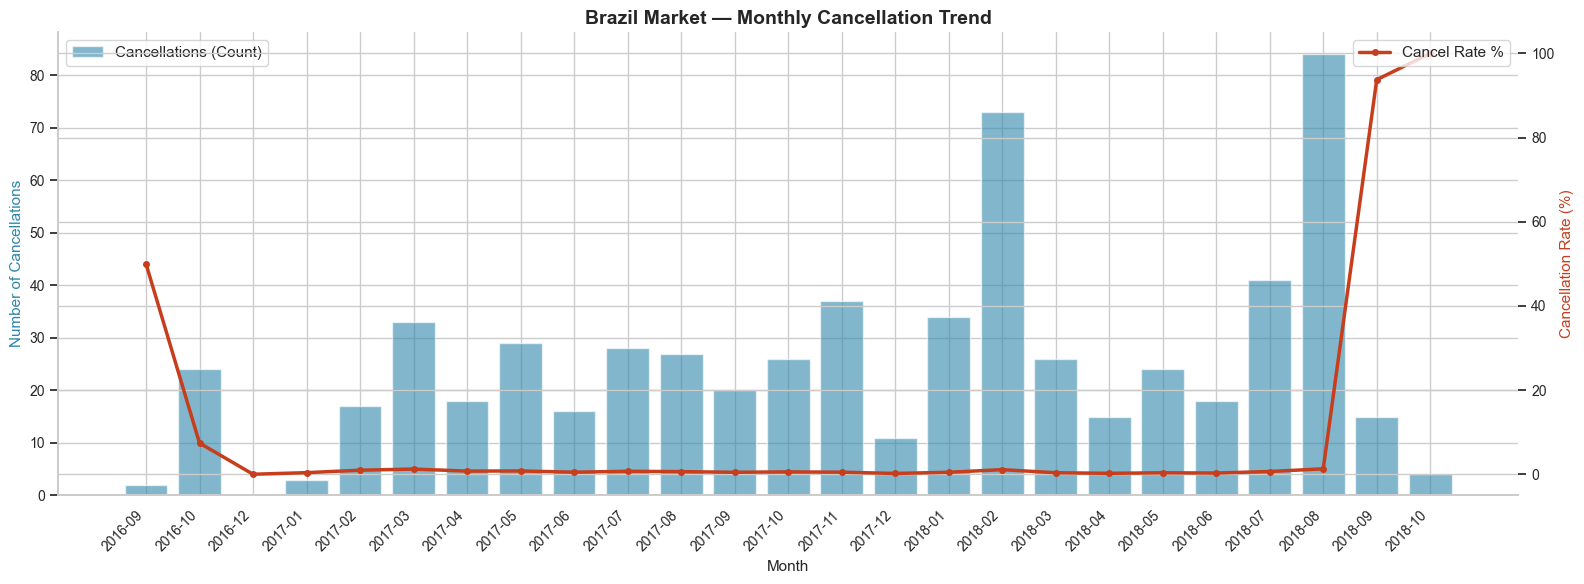

Brazil Market — Key Findings
Cancellation Rate    : 0.63%
Late Delivery Rate   : 6.77%
Avg Review Score     : 4.08/5
Worst Cancel Cat     : Dvds Blu Ray (3.5%)
Worst Cancel State   : RO (1.2%)


In [14]:
# Order Status Distribution
status_counts = df_brazil['order_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Brazil Market — Order Status Distribution', fontsize=16, fontweight='bold')

# Donut chart
axes[0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=COLORS[:len(status_counts)],
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
axes[0].set_title('Order Status — Proportional Split')

# Bar chart
bar_colors = [COLORS[0] if s == 'delivered' else COLORS[3] if s == 'canceled' else COLORS[5]
              for s in status_counts.index]
bars = axes[1].bar(status_counts.index, status_counts.values,
                   color=bar_colors, edgecolor='white')
axes[1].set_title('Order Count by Status')
axes[1].set_xlabel('Order Status')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('brazil_order_status.png', dpi=150, bbox_inches='tight')
plt.show()

# Delivery Delay vs Review Score
delay_review = (
    delivered.dropna(subset=['delivery_delay_days', 'review_score'])
    .groupby('review_score')['delivery_delay_days']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Avg_Delay', 'median': 'Median_Delay', 'count': 'Order_Count'})
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Brazil Market — Delivery Delay vs Customer Satisfaction', fontsize=16, fontweight='bold')

axes[0].bar(delay_review['review_score'], delay_review['Avg_Delay'],
            color=[COLORS[3] if v > 0 else COLORS[4] for v in delay_review['Avg_Delay']],
            edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[0].set_title('Avg Delivery Delay (days) by Review Score')
axes[0].set_xlabel('Review Score (1 = Worst, 5 = Best)')
axes[0].set_ylabel('Average Delay (days)')
axes[0].set_xticks([1, 2, 3, 4, 5])

delivered_copy = delivered.dropna(subset=['is_late', 'review_score']).copy()
delivered_copy['Delivery'] = delivered_copy['is_late'].map({True: 'Late', False: 'On Time'})
sns.boxplot(data=delivered_copy, x='Delivery', y='review_score',
            palette={'Late': '#C73E1D', 'On Time': '#44BBA4'}, ax=axes[1])
axes[1].set_title('Review Score Distribution: Late vs On-Time Delivery')
axes[1].set_xlabel('Delivery Status')
axes[1].set_ylabel('Review Score (1–5)')

plt.tight_layout()
plt.savefig('brazil_delay_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()

# Top Categories by Cancellation Rate
cat_perf = (
    df_brazil.dropna(subset=['product_category'])
    .groupby('product_category')
    .agg(
        Total_Orders  = ('order_id', 'count'),
        Cancellations = ('is_cancelled', 'sum'),
        Avg_Value     = ('total_value', 'mean'),
        Avg_Review    = ('review_score', 'mean')
    )
    .reset_index()
)
cat_perf['Cancel_Rate_%'] = (cat_perf['Cancellations'] / cat_perf['Total_Orders'] * 100).round(2)
cat_perf = cat_perf[cat_perf['Total_Orders'] >= 50]

top_cancel_cats  = cat_perf.sort_values('Cancel_Rate_%', ascending=False).head(15)
top_revenue_cats = cat_perf.sort_values('Total_Orders', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('Brazil Market — Product Category Analysis', fontsize=16, fontweight='bold')

axes[0].barh(top_cancel_cats['product_category'], top_cancel_cats['Cancel_Rate_%'],
             color=COLORS[1], edgecolor='white')
axes[0].set_title('Top 15 Categories by Cancellation Rate (%)')
axes[0].set_xlabel('Cancellation Rate (%)')
axes[0].invert_yaxis()

axes[1].barh(top_revenue_cats['product_category'], top_revenue_cats['Total_Orders'],
             color=COLORS[0], edgecolor='white')
axes[1].set_title('Top 10 Categories by Order Volume')
axes[1].set_xlabel('Total Orders')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('brazil_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# State-wise Performance
state_perf = (
    df_brazil.groupby('customer_state')
    .agg(
        Total_Orders  = ('order_id', 'count'),
        Cancellations = ('is_cancelled', 'sum'),
        Avg_Review    = ('review_score', 'mean')
    )
    .reset_index()
)
state_perf['Cancel_Rate_%'] = (state_perf['Cancellations'] / state_perf['Total_Orders'] * 100).round(2)
state_perf = state_perf[state_perf['Total_Orders'] >= 100].sort_values('Cancel_Rate_%', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Brazil Market — State-wise Performance', fontsize=16, fontweight='bold')

axes[0].barh(state_perf['customer_state'], state_perf['Cancel_Rate_%'],
             color=COLORS[3], edgecolor='white')
axes[0].set_title('Cancellation Rate by State (Top 15)')
axes[0].set_xlabel('Cancellation Rate (%)')
axes[0].invert_yaxis()

axes[1].barh(state_perf['customer_state'], state_perf['Avg_Review'],
             color=COLORS[4], edgecolor='white')
axes[1].set_title('Average Review Score by State')
axes[1].set_xlabel('Average Review Score (1–5)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('brazil_state_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Monthly Cancellation Trend
monthly_cancel = (
    df_brazil.groupby('YearMonth')
    .agg(Total=('order_id', 'count'), Cancelled=('is_cancelled', 'sum'))
    .reset_index()
    .sort_values('YearMonth')
)
monthly_cancel['Cancel_Rate_%'] = (monthly_cancel['Cancelled'] / monthly_cancel['Total'] * 100).round(2)

fig, ax = plt.subplots(figsize=(16, 6))
ax2 = ax.twinx()
ax.bar(range(len(monthly_cancel)), monthly_cancel['Cancelled'],
       color=COLORS[0], alpha=0.6, label='Cancellations (Count)')
ax2.plot(range(len(monthly_cancel)), monthly_cancel['Cancel_Rate_%'],
         color=COLORS[3], linewidth=2.5, marker='o', markersize=4, label='Cancel Rate %')
ax.set_title('Brazil Market — Monthly Cancellation Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Cancellations', color=COLORS[0])
ax2.set_ylabel('Cancellation Rate (%)', color=COLORS[3])
ax.set_xticks(range(len(monthly_cancel)))
ax.set_xticklabels(monthly_cancel['YearMonth'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('brazil_monthly_cancellations.png', dpi=150, bbox_inches='tight')
plt.show()

# Key Findings
print("Brazil Market — Key Findings")
print(f"Cancellation Rate    : {df_brazil['is_cancelled'].mean()*100:.2f}%")
print(f"Late Delivery Rate   : {delivered['is_late'].mean()*100:.2f}%")
print(f"Avg Review Score     : {df_brazil['review_score'].mean():.2f}/5")
print(f"Worst Cancel Cat     : {top_cancel_cats.iloc[0]['product_category']} "
      f"({top_cancel_cats.iloc[0]['Cancel_Rate_%']:.1f}%)")
print(f"Worst Cancel State   : {state_perf.iloc[0]['customer_state']} "
      f"({state_perf.iloc[0]['Cancel_Rate_%']:.1f}%)")

### LOGISTICS — E-COMMERCE SHIPPING ANALYSIS

Shape: (10999, 12)
Columns: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Late_Delivery']
Missing Values:
 ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Late_Delivery          0
dtype: int64
Basic Statistics:


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Late_Delivery
count,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00
mean,5500.00,4.05,2.99,210.20,3.57,13.37,3634.02,0.60
std,3175.28,1.14,1.41,48.06,1.52,16.21,1635.38,0.49
min,1.00,2.00,1.00,96.00,2.00,1.00,1001.00,0.00
25%,2750.50,3.00,2.00,169.00,3.00,4.00,1839.50,0.00
50%,5500.00,4.00,3.00,214.00,3.00,7.00,4149.00,1.00
75%,8249.50,5.00,4.00,251.00,4.00,10.00,5050.00,1.00
max,10999.00,7.00,5.00,310.00,10.00,65.00,7846.00,1.00


Logistics Dataset — Summary
Total Shipments      : 10,999
Late Deliveries      : 6,563
Late Delivery Rate   : 59.67%
Avg Customer Rating  : 2.99/5
Avg Care Calls       : 4.05
Warehouses           : ['D' 'F' 'A' 'B' 'C']
Shipment Modes       : ['Flight' 'Ship' 'Road']


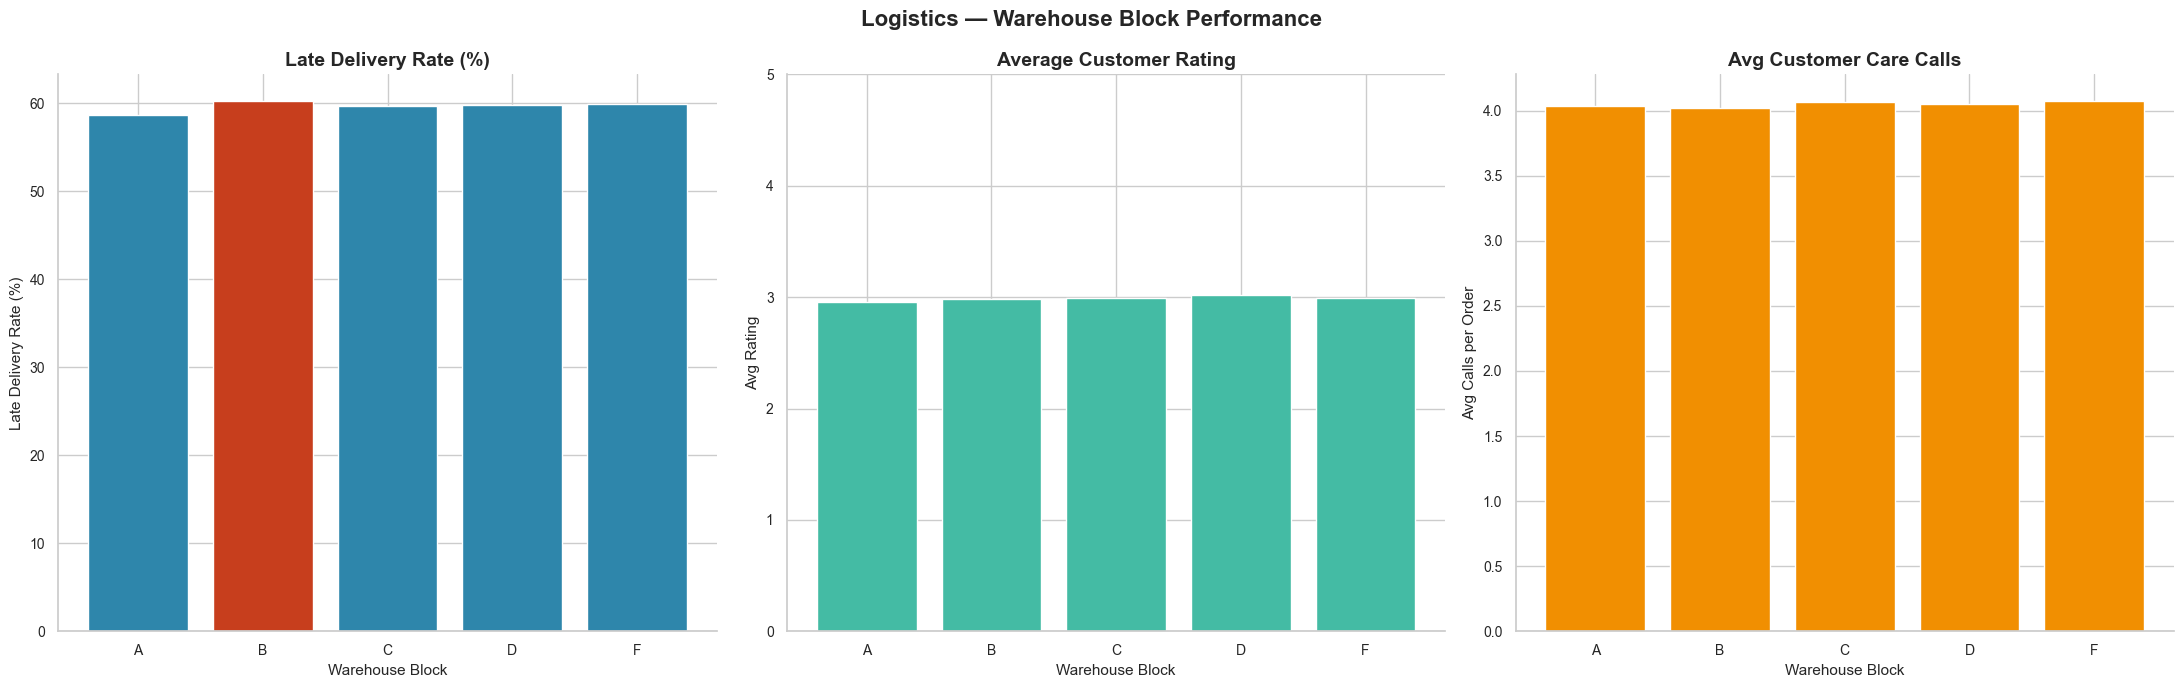

,Warehouse_block,Total_Shipments,Late_Deliveries,Avg_Rating,Avg_Care_Calls,Avg_Discount,Late_Rate_%
1,B,1833,1104,2.98,4.02,13.19,60.23
4,F,3666,2194,3.00,4.08,13.67,59.85
3,D,1834,1096,3.02,4.05,13.09,59.76
2,C,1833,1094,2.99,4.06,13.40,59.68
0,A,1833,1075,2.96,4.04,13.22,58.65


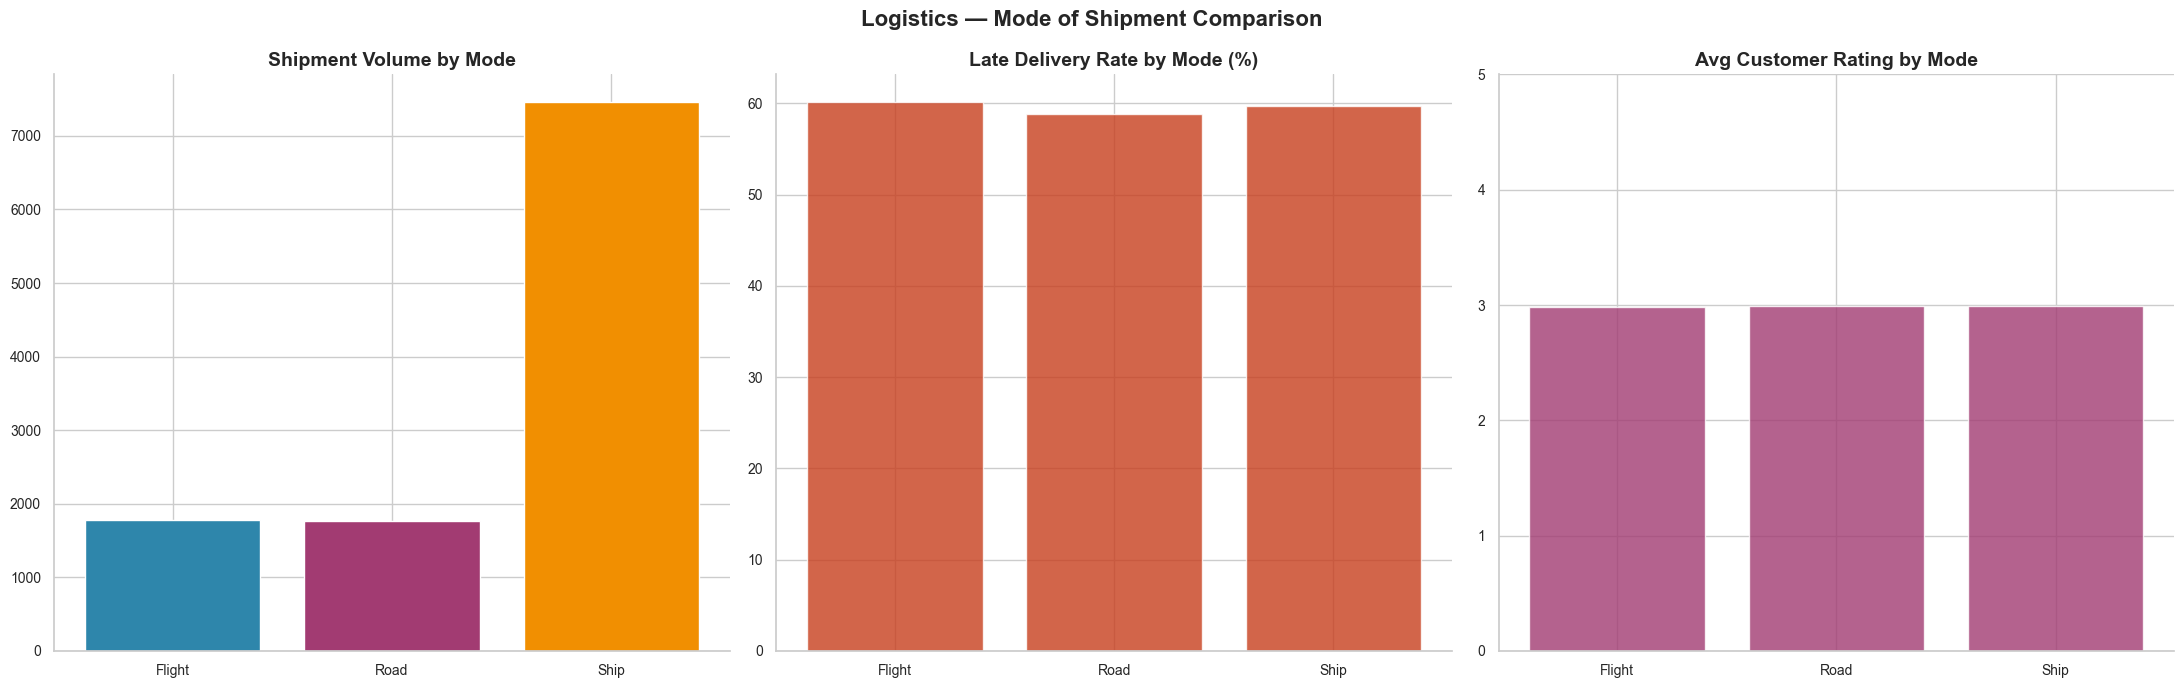

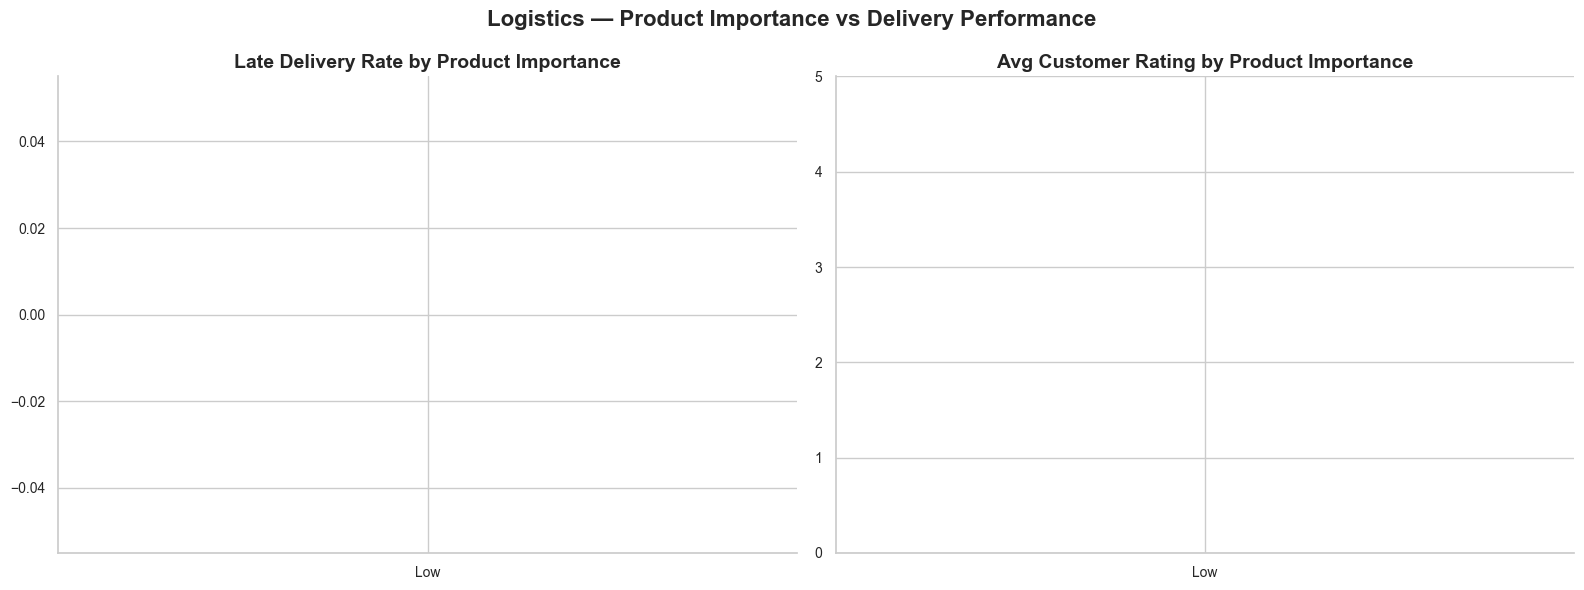

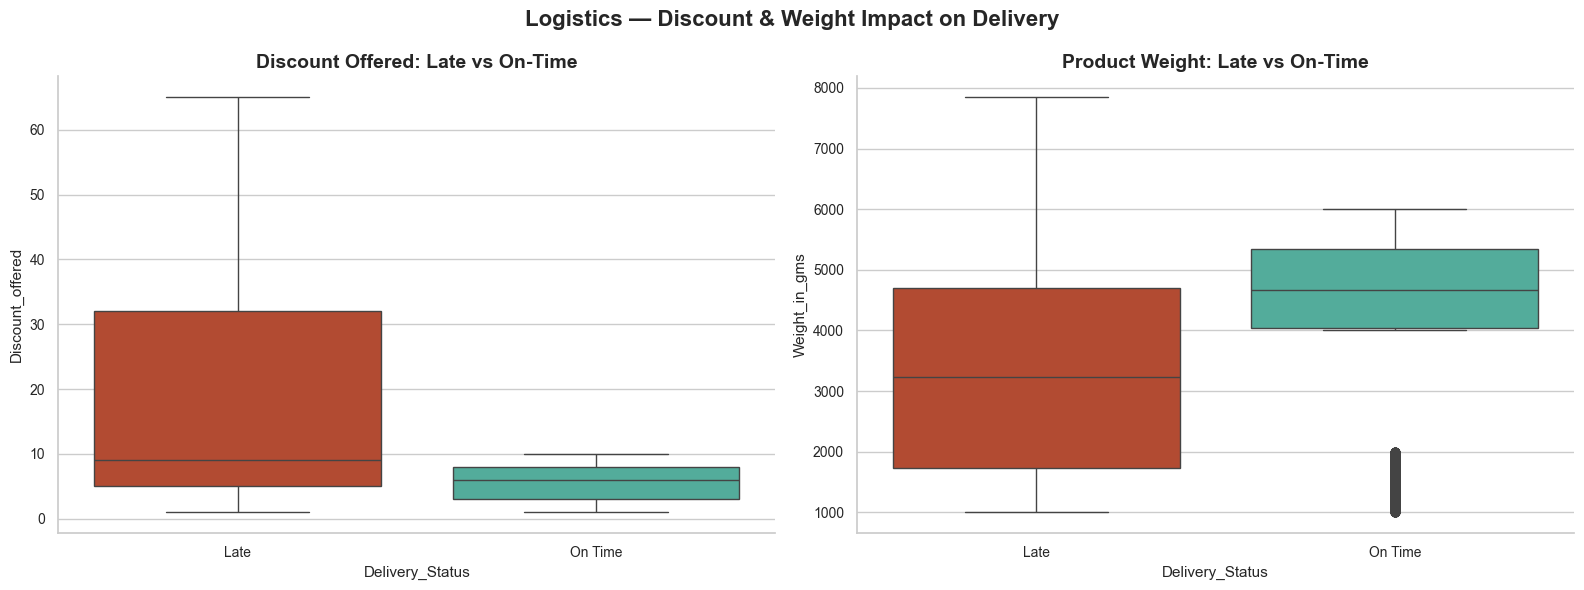

Logistics — Key Findings
Overall Late Rate    : 59.67%
Worst Warehouse      : B (60.2% late)
Best Shipment Mode   : Road
Avg Rating           : 2.99/5
Avg Care Calls       : 4.05


In [16]:
# 7.1 Data Cleaning
df_lg = df_ship.copy()
df_lg.columns = (df_lg.columns
                 .str.strip()
                 .str.replace(' ', '_')
                 .str.replace('.', '_', regex=False))

# Identify the late delivery column
time_col = [c for c in df_lg.columns if 'Reached' in c or 'Time' in c]
if time_col:
    df_lg.rename(columns={time_col[0]: 'Late_Delivery'}, inplace=True)
else:
    raise ValueError("Cannot find delivery time column. Check column names above.")

print(f"Shape: {df_lg.shape}")
print(f"Columns: {list(df_lg.columns)}")
print("Missing Values:\n", df_lg.isnull().sum())
print("Basic Statistics:")
display(df_lg.describe())
print("Logistics Dataset — Summary")
print(f"Total Shipments      : {len(df_lg):,}")
print(f"Late Deliveries      : {df_lg['Late_Delivery'].sum():,}")
print(f"Late Delivery Rate   : {df_lg['Late_Delivery'].mean()*100:.2f}%")
print(f"Avg Customer Rating  : {df_lg['Customer_rating'].mean():.2f}/5")
print(f"Avg Care Calls       : {df_lg['Customer_care_calls'].mean():.2f}")
print(f"Warehouses           : {df_lg['Warehouse_block'].unique()}")
print(f"Shipment Modes       : {df_lg['Mode_of_Shipment'].unique()}")

# 7.2 Warehouse Performance
wh_perf = (
    df_lg.groupby('Warehouse_block')
    .agg(
        Total_Shipments = ('ID', 'count'),
        Late_Deliveries = ('Late_Delivery', 'sum'),
        Avg_Rating      = ('Customer_rating', 'mean'),
        Avg_Care_Calls  = ('Customer_care_calls', 'mean'),
        Avg_Discount    = ('Discount_offered', 'mean')
    )
    .reset_index()
)
wh_perf['Late_Rate_%'] = (wh_perf['Late_Deliveries'] / wh_perf['Total_Shipments'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Logistics — Warehouse Block Performance', fontsize=16, fontweight='bold')

worst_wh = wh_perf.sort_values('Late_Rate_%', ascending=False).iloc[0]['Warehouse_block']
colors_wh = [COLORS[3] if w == worst_wh else COLORS[0] for w in wh_perf['Warehouse_block']]

axes[0].bar(wh_perf['Warehouse_block'], wh_perf['Late_Rate_%'],
            color=colors_wh, edgecolor='white')
axes[0].set_title('Late Delivery Rate (%)')
axes[0].set_xlabel('Warehouse Block')
axes[0].set_ylabel('Late Delivery Rate (%)')

axes[1].bar(wh_perf['Warehouse_block'], wh_perf['Avg_Rating'],
            color=COLORS[4], edgecolor='white')
axes[1].set_title('Average Customer Rating')
axes[1].set_xlabel('Warehouse Block')
axes[1].set_ylabel('Avg Rating')
axes[1].set_ylim(0, 5)

axes[2].bar(wh_perf['Warehouse_block'], wh_perf['Avg_Care_Calls'],
            color=COLORS[2], edgecolor='white')
axes[2].set_title('Avg Customer Care Calls')
axes[2].set_xlabel('Warehouse Block')
axes[2].set_ylabel('Avg Calls per Order')

plt.tight_layout()
plt.savefig('logistics_warehouse.png', dpi=150, bbox_inches='tight')
plt.show()
display(wh_perf.sort_values('Late_Rate_%', ascending=False))

# 7.3 Shipment Mode Analysis
mode_perf = (
    df_lg.groupby('Mode_of_Shipment')
    .agg(
        Volume         = ('ID', 'count'),
        Late_Rate      = ('Late_Delivery', 'mean'),
        Avg_Rating     = ('Customer_rating', 'mean'),
        Avg_Cost       = ('Cost_of_the_Product', 'mean'),
        Avg_Weight     = ('Weight_in_gms', 'mean'),
        Avg_Discount   = ('Discount_offered', 'mean')
    )
    .reset_index()
)
mode_perf['Late_Rate_%'] = (mode_perf['Late_Rate'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Logistics — Mode of Shipment Comparison', fontsize=16, fontweight='bold')

axes[0].bar(mode_perf['Mode_of_Shipment'], mode_perf['Volume'],
            color=COLORS[:len(mode_perf)], edgecolor='white')
axes[0].set_title('Shipment Volume by Mode')

axes[1].bar(mode_perf['Mode_of_Shipment'], mode_perf['Late_Rate_%'],
            color=COLORS[3], alpha=0.8, edgecolor='white')
axes[1].set_title('Late Delivery Rate by Mode (%)')

axes[2].bar(mode_perf['Mode_of_Shipment'], mode_perf['Avg_Rating'],
            color=COLORS[1], alpha=0.8, edgecolor='white')
axes[2].set_title('Avg Customer Rating by Mode')
axes[2].set_ylim(0, 5)

plt.tight_layout()
plt.savefig('logistics_shipment_mode.png', dpi=150, bbox_inches='tight')
plt.show()

# 7.4 Product Importance vs Delivery
imp_order = ['Low', 'Medium', 'High']
imp_perf = (
    df_lg.groupby('Product_importance')
    .agg(Count=('ID', 'count'), Late_Rate=('Late_Delivery', 'mean'),
         Avg_Rating=('Customer_rating', 'mean'))
    .reset_index()
)
imp_perf['Late_Rate_%'] = (imp_perf['Late_Rate'] * 100).round(2)
imp_perf = imp_perf.set_index('Product_importance').reindex(imp_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Logistics — Product Importance vs Delivery Performance', fontsize=16, fontweight='bold')

axes[0].bar(imp_perf['Product_importance'], imp_perf['Late_Rate_%'],
            color=[COLORS[4], COLORS[2], COLORS[3]], edgecolor='white')
axes[0].set_title('Late Delivery Rate by Product Importance')

axes[1].bar(imp_perf['Product_importance'], imp_perf['Avg_Rating'],
            color=[COLORS[4], COLORS[2], COLORS[3]], edgecolor='white')
axes[1].set_title('Avg Customer Rating by Product Importance')
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.savefig('logistics_product_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 7.5 Discount & Weight vs Late Delivery
df_lg['Delivery_Status'] = df_lg['Late_Delivery'].map({1: 'Late', 0: 'On Time'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Logistics — Discount & Weight Impact on Delivery', fontsize=16, fontweight='bold')

sns.boxplot(data=df_lg, x='Delivery_Status', y='Discount_offered',
            palette={'On Time': '#44BBA4', 'Late': '#C73E1D'}, ax=axes[0])
axes[0].set_title('Discount Offered: Late vs On-Time')

sns.boxplot(data=df_lg, x='Delivery_Status', y='Weight_in_gms',
            palette={'On Time': '#44BBA4', 'Late': '#C73E1D'}, ax=axes[1])
axes[1].set_title('Product Weight: Late vs On-Time')

plt.tight_layout()
plt.savefig('logistics_discount_weight.png', dpi=150, bbox_inches='tight')
plt.show()

# Key Findings
print("Logistics — Key Findings")
print(f"Overall Late Rate    : {df_lg['Late_Delivery'].mean()*100:.2f}%")
print(f"Worst Warehouse      : {wh_perf.sort_values('Late_Rate_%', ascending=False).iloc[0]['Warehouse_block']} "
      f"({wh_perf.sort_values('Late_Rate_%', ascending=False).iloc[0]['Late_Rate_%']:.1f}% late)")
print(f"Best Shipment Mode   : {mode_perf.sort_values('Late_Rate_%').iloc[0]['Mode_of_Shipment']}")
print(f"Avg Rating           : {df_lg['Customer_rating'].mean():.2f}/5")
print(f"Avg Care Calls       : {df_lg['Customer_care_calls'].mean():.2f}")

### CROSS-MARKET EXECUTIVE DASHBOARD

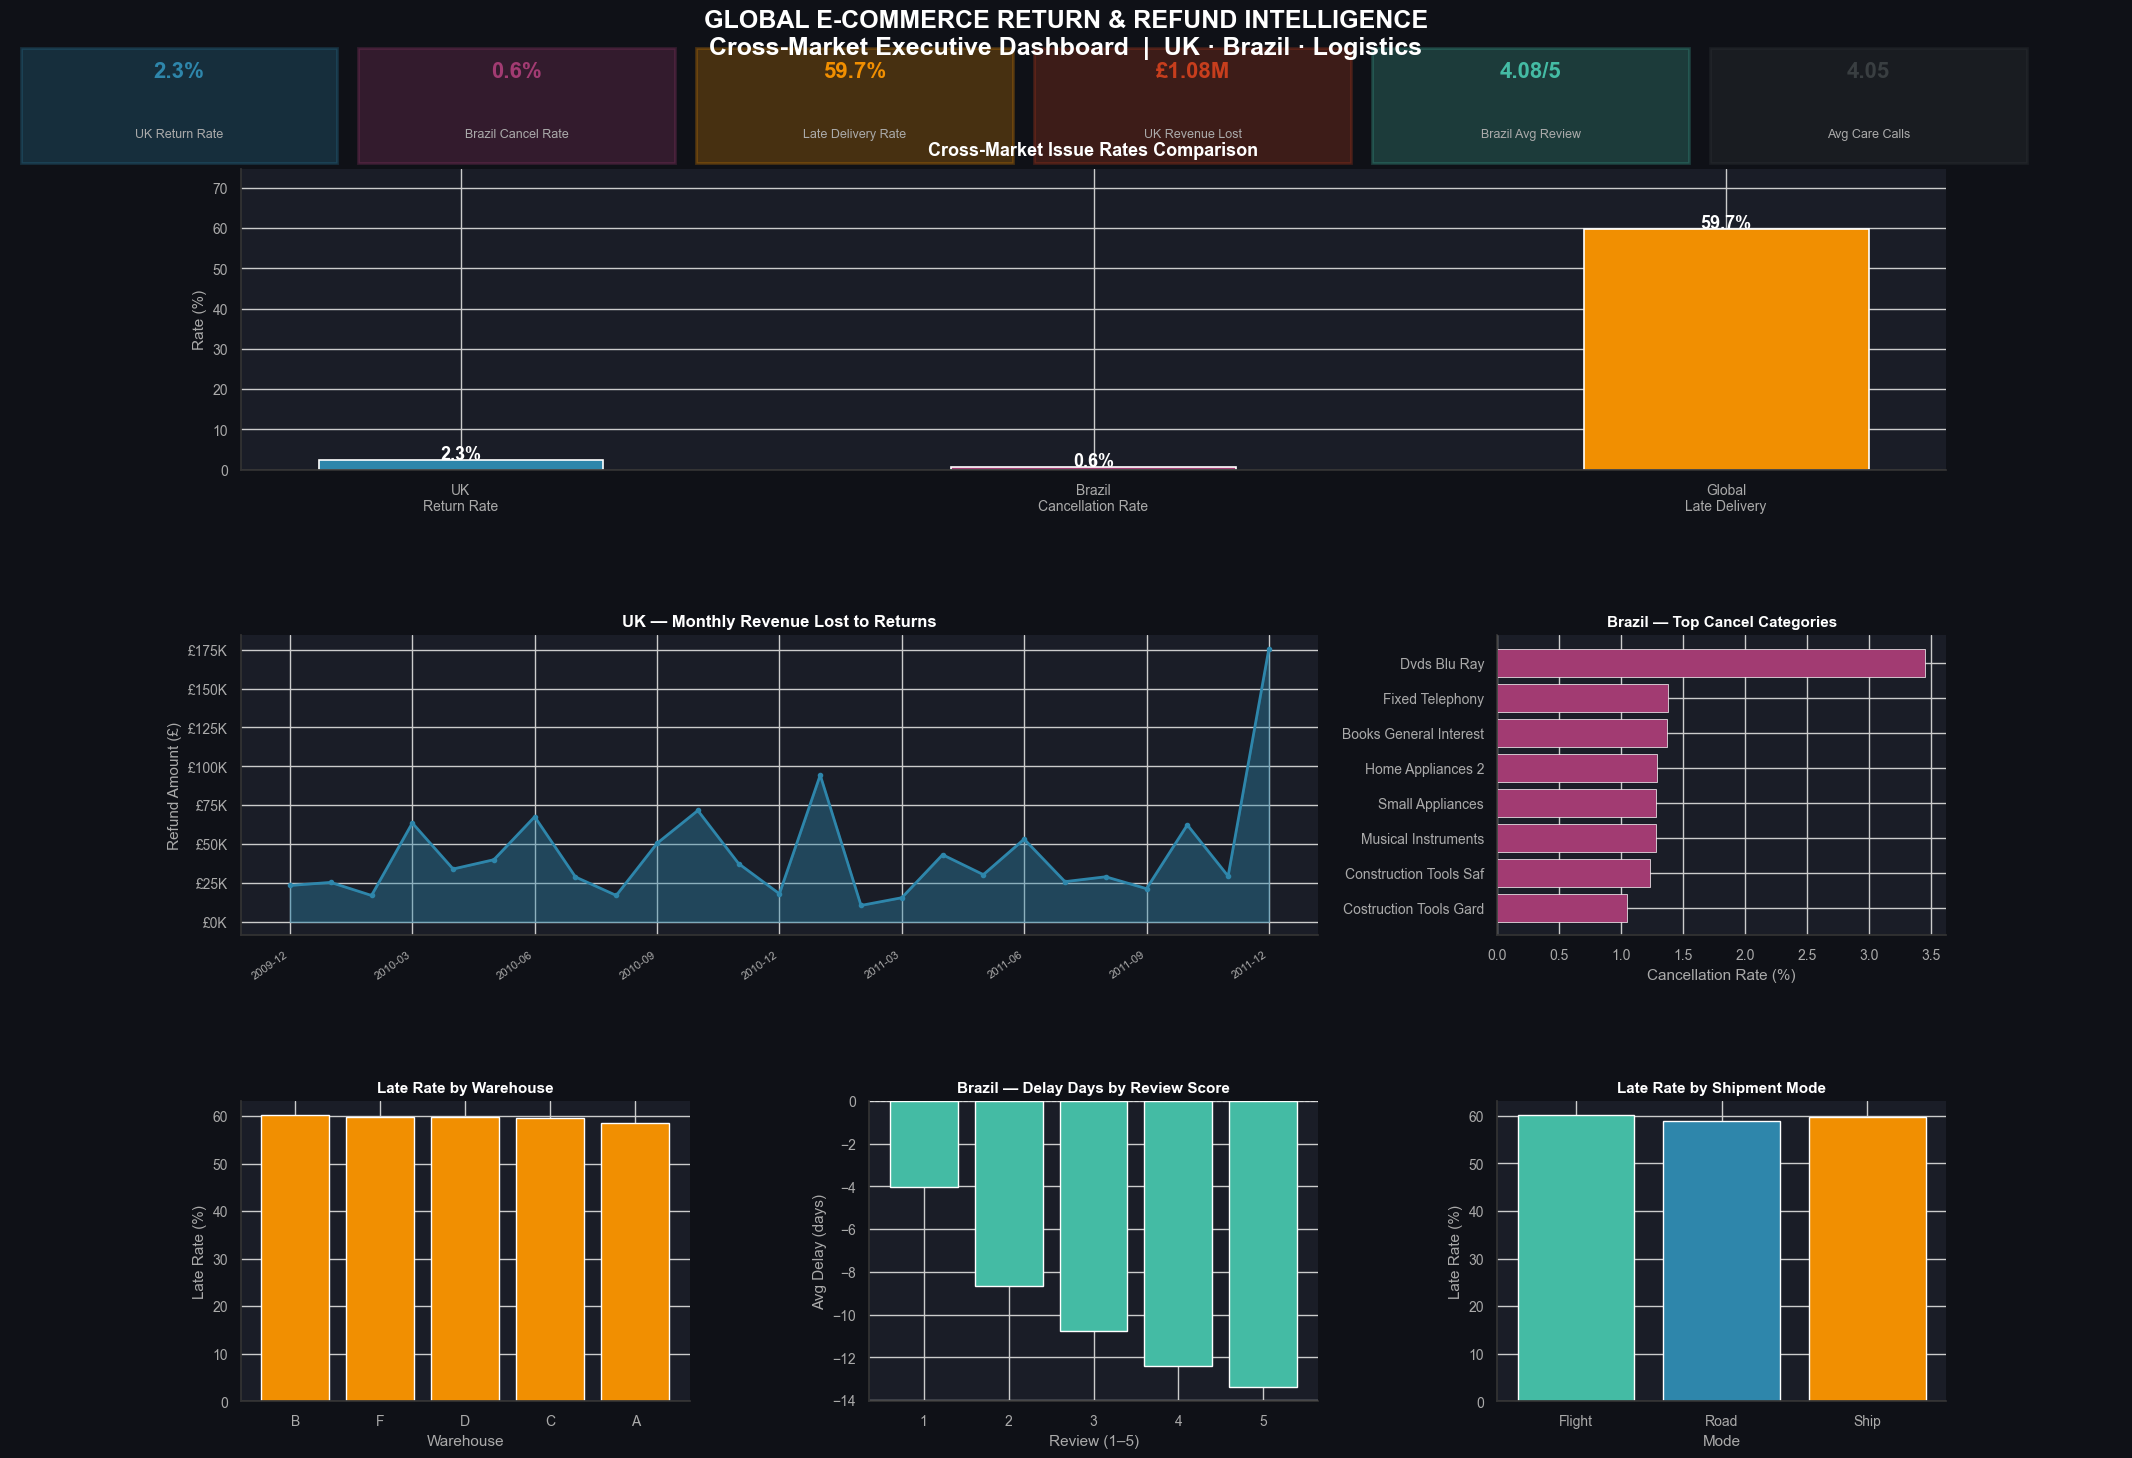

Saved: cross_market_dashboard.png


In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor('#0F1117')
fig.suptitle(
    'GLOBAL E-COMMERCE RETURN & REFUND INTELLIGENCE\n'
    'Cross-Market Executive Dashboard  |  UK · Brazil · Logistics',
    fontsize=18, fontweight='bold', color='white', y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# KPI Cards
kpi_data = [
    ('UK Return Rate',     f"{len(df_uk_returns)/len(df_uk)*100:.1f}%",    '#2E86AB'),
    ('Brazil Cancel Rate', f"{df_brazil['is_cancelled'].mean()*100:.1f}%", '#A23B72'),
    ('Late Delivery Rate', f"{df_lg['Late_Delivery'].mean()*100:.1f}%",    '#F18F01'),
    ('UK Revenue Lost',    f"£{df_uk_returns['RefundAmount'].sum()/1e6:.2f}M", '#C73E1D'),
    ('Brazil Avg Review',  f"{df_brazil['review_score'].mean():.2f}/5",    '#44BBA4'),
    ('Avg Care Calls',     f"{df_lg['Customer_care_calls'].mean():.2f}",   '#393E41'),
]

ax_kpi = fig.add_axes([0.02, 0.88, 0.96, 0.08])
ax_kpi.set_facecolor('#0F1117')
ax_kpi.axis('off')
for i, (label, value, color) in enumerate(kpi_data):
    x = 0.08 + i * 0.16
    ax_kpi.add_patch(plt.Rectangle((x - 0.075, 0.05), 0.15, 0.9,
                                   facecolor=color, alpha=0.25,
                                   transform=ax_kpi.transAxes, clip_on=False,
                                   linewidth=2, edgecolor=color))
    ax_kpi.text(x, 0.72, value, transform=ax_kpi.transAxes,
                ha='center', fontsize=16, fontweight='bold', color=color)
    ax_kpi.text(x, 0.25, label, transform=ax_kpi.transAxes,
                ha='center', fontsize=9, color='#AAAAAA')

# Chart 1: Cross-Market Issue Rates
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#1A1D27')
markets = ['UK\nReturn Rate', 'Brazil\nCancellation Rate', 'Global\nLate Delivery']
rates = [
    len(df_uk_returns)/len(df_uk)*100,
    df_brazil['is_cancelled'].mean()*100,
    df_lg['Late_Delivery'].mean()*100
]
bar_colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax1.bar(markets, rates, color=bar_colors, width=0.45, edgecolor='white', linewidth=1.2)
ax1.set_title('Cross-Market Issue Rates Comparison', color='white', fontsize=13, pad=10)
ax1.set_ylabel('Rate (%)', color='#AAAAAA')
ax1.tick_params(colors='#AAAAAA')
for spine in ax1.spines.values():
    spine.set_color('#333333')
for bar, val in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold', color='white')
ax1.set_ylim(0, max(rates) * 1.25)

# Chart 2: UK Monthly Revenue Lost
ax2 = fig.add_subplot(gs[1, :2])
ax2.set_facecolor('#1A1D27')
x = range(len(monthly))
ax2.fill_between(x, monthly['Total_Refund'], color='#2E86AB', alpha=0.4)
ax2.plot(x, monthly['Total_Refund'], color='#2E86AB', linewidth=2, marker='o', markersize=3)
ax2.set_title('UK — Monthly Revenue Lost to Returns', color='white', fontsize=12)
ax2.set_ylabel('Refund Amount (£)', color='#AAAAAA')
ax2.tick_params(colors='#AAAAAA')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'£{v/1000:.0f}K'))
ax2.set_xticks(range(0, len(monthly), 3))
ax2.set_xticklabels(monthly['YearMonth'].iloc[::3], rotation=35, ha='right', fontsize=8, color='#AAAAAA')
for spine in ax2.spines.values():
    spine.set_color('#333333')

# Chart 3: Brazil Category Cancel Rate (Top 8)
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor('#1A1D27')
top8 = top_cancel_cats.head(8)
ax3.barh(top8['product_category'].str[:22], top8['Cancel_Rate_%'],
         color='#A23B72', edgecolor='white', linewidth=0.5)
ax3.set_title('Brazil — Top Cancel Categories', color='white', fontsize=11)
ax3.set_xlabel('Cancellation Rate (%)', color='#AAAAAA')
ax3.tick_params(colors='#AAAAAA')
ax3.invert_yaxis()
for spine in ax3.spines.values():
    spine.set_color('#333333')

# Chart 4: Logistics Warehouse Late Rates
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor('#1A1D27')
wh_sorted = wh_perf.sort_values('Late_Rate_%', ascending=False)
ax4.bar(wh_sorted['Warehouse_block'], wh_sorted['Late_Rate_%'],
        color='#F18F01', edgecolor='white')
ax4.set_title('Late Rate by Warehouse', color='white', fontsize=11)
ax4.set_xlabel('Warehouse', color='#AAAAAA')
ax4.set_ylabel('Late Rate (%)', color='#AAAAAA')
ax4.tick_params(colors='#AAAAAA')
for spine in ax4.spines.values():
    spine.set_color('#333333')

# Chart 5: Delay vs Review (Brazil)
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor('#1A1D27')
bar_cols = ['#C73E1D' if v > 0 else '#44BBA4' for v in delay_review['Avg_Delay']]
ax5.bar(delay_review['review_score'], delay_review['Avg_Delay'],
        color=bar_cols, edgecolor='white')
ax5.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.4)
ax5.set_title('Brazil — Delay Days by Review Score', color='white', fontsize=11)
ax5.set_xlabel('Review (1–5)', color='#AAAAAA')
ax5.set_ylabel('Avg Delay (days)', color='#AAAAAA')
ax5.set_xticks([1, 2, 3, 4, 5])
ax5.tick_params(colors='#AAAAAA')
for spine in ax5.spines.values():
    spine.set_color('#333333')

# Chart 6: Shipment Mode Comparison
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor('#1A1D27')
ax6.bar(mode_perf['Mode_of_Shipment'], mode_perf['Late_Rate_%'],
        color=['#44BBA4', '#2E86AB', '#F18F01'][:len(mode_perf)], edgecolor='white')
ax6.set_title('Late Rate by Shipment Mode', color='white', fontsize=11)
ax6.set_xlabel('Mode', color='#AAAAAA')
ax6.set_ylabel('Late Rate (%)', color='#AAAAAA')
ax6.tick_params(colors='#AAAAAA')
for spine in ax6.spines.values():
    spine.set_color('#333333')

plt.savefig('cross_market_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print("Saved: cross_market_dashboard.png")

### BUSINESS RECOMMENDATIONS

In [26]:
import pandas as pd

uk_market = pd.DataFrame({
    "Key Insights": [
        "Top returned products often have vague descriptions",
        "Return rate spikes in Q4 (holiday season)",
        "UK dominates returns volume – international returns are small but disproportionately costly per unit",
        "Peak return day identified via SQL Q5"
    ],
    "Recommended Actions": [
        "Improve product listings with images & specifications",
        "Implement stricter holiday return window policies",
        "Allocate resources to manage costly international returns",
        "Staff return-processing teams on peak return day"
    ]
})

uk_market

,Key Insights,Recommended Actions
0,Top returned products often have vague descrip...,Improve product listings with images & specifi...
1,Return rate spikes in Q4 (holiday season),Implement stricter holiday return window policies
2,UK dominates returns volume – international re...,Allocate resources to manage costly internatio...
3,Peak return day identified via SQL Q5,Staff return-processing teams on peak return day


In [27]:
brazil_market = pd.DataFrame({
    "Key Insights": [
        "1-star reviews strongly correlate with late delivery",
        "High-value order segments have higher cancel rates",
        "Top cancel categories need root-cause review (pricing, quality, misleading descriptions)",
        "Pre-cancellation SMS/email can reduce 15–25% of avoidable cancellations"
    ],
    "Recommended Actions": [
        "Reduce delivery delays in worst 3 states (SQL Q9)",
        "Offer proactive updates for orders >$150",
        "Investigate cancel-prone categories for quality/pricing issues",
        "Implement pre-cancellation communication (SMS/email)"
    ]
})

brazil_market

,Key Insights,Recommended Actions
0,1-star reviews strongly correlate with late de...,Reduce delivery delays in worst 3 states (SQL Q9)
1,High-value order segments have higher cancel r...,Offer proactive updates for orders >$150
2,Top cancel categories need root-cause review (...,Investigate cancel-prone categories for qualit...
3,Pre-cancellation SMS/email can reduce 15–25% o...,Implement pre-cancellation communication (SMS/...


In [28]:
global_logistics = pd.DataFrame({
    "Logistics Issue": [
        "Worst-performing warehouse",
        "High-importance products have no delivery priority",
        "Customers with 4+ care calls show very low ratings",
        "Large discounts correlate with late delivery"
    ],
    "Recommended Action": [
        "Conduct urgent operational audit",
        "Create priority dispatch queue for high-importance items",
        "Invest in First-Call Resolution (FCR) training",
        "Audit whether discounts cause overloaded or understaffed routes"
    ]
})

global_logistics

,Logistics Issue,Recommended Action
0,Worst-performing warehouse,Conduct urgent operational audit
1,High-importance products have no delivery prio...,Create priority dispatch queue for high-import...
2,Customers with 4+ care calls show very low rat...,Invest in First-Call Resolution (FCR) training
3,Large discounts correlate with late delivery,Audit whether discounts cause overloaded or un...


### PROJECT SUMMARY & NEXT STEPS

In [29]:
import pandas as pd

project_summary = pd.DataFrame({
    "Domain": ["UK Market", "Brazil Market", "Global Logistics"],
    "Summary": [
        "High return rates driven by vague product descriptions and seasonal spikes; international returns costly per unit.",
        "Cancellations linked to late deliveries, high-value orders, and cancel-prone categories; reviews highlight delivery issues.",
        "Operational inefficiencies in warehouses, lack of delivery prioritization, poor customer service outcomes, and discount-related delays."
    ],
    "Next Steps": [
        "Enhance product listings, tighten holiday return policies, allocate resources for international returns, staff peak return days.",
        "Reduce delivery delays in worst states, provide proactive updates for high-value orders, investigate cancel categories, implement pre-cancellation communication.",
        "Audit worst-performing warehouse, establish priority dispatch for high-importance items, invest in FCR training, review discount-related delivery bottlenecks."
    ]
})

project_summary

,Domain,Summary,Next Steps
0,UK Market,High return rates driven by vague product desc...,"Enhance product listings, tighten holiday retu..."
1,Brazil Market,"Cancellations linked to late deliveries, high-...","Reduce delivery delays in worst states, provid..."
2,Global Logistics,"Operational inefficiencies in warehouses, lack...","Audit worst-performing warehouse, establish pr..."
